<a href="https://colab.research.google.com/github/GaniuKuku/aisip-ml-portfolio/blob/main/Analysis_African_Crises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Setup and Loading**

In [1]:
!pip install kagglehub -q

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download latest version
path = kagglehub.dataset_download("chirin/africa-economic-banking-and-systemic-crisis-data")

# The path returned is a directory; we need to find the CSV inside it
import os
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print(f"Dataset loaded from: {path}")

100%|██████████| 13.7k/13.7k [00:00<00:00, 15.2MB/s]

Extracting files...
Dataset loaded from: /root/.cache/kagglehub/datasets/chirin/africa-economic-banking-and-systemic-crisis-data/versions/1


**The EDA & Cleaning Workflow**








Load with Pandas, exploring with .shape, .info(), .describe().

In [3]:
print("Shape:", df.shape)


Shape: (1059, 14)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1059 entries, 0 to 1058
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   case                             1059 non-null   int64  
 1   cc3                              1059 non-null   object 
 2   country                          1059 non-null   object 
 3   year                             1059 non-null   int64  
 4   systemic_crisis                  1059 non-null   int64  
 5   exch_usd                         1059 non-null   float64
 6   domestic_debt_in_default         1059 non-null   int64  
 7   sovereign_external_debt_default  1059 non-null   int64  
 8   gdp_weighted_default             1059 non-null   float64
 9   inflation_annual_cpi             1059 non-null   float64
 10  independence                     1059 non-null   int64  
 11  currency_crises                  1059 non-null   int64  
 12  inflation_crises    

In [5]:
print(df.describe())

              case         year  systemic_crisis     exch_usd  \
count  1059.000000  1059.000000      1059.000000  1059.000000   
mean     35.613787  1967.767705         0.077432    43.140831   
std      23.692402    33.530632         0.267401   111.475380   
min       1.000000  1860.000000         0.000000     0.000000   
25%      15.000000  1951.000000         0.000000     0.195350   
50%      38.000000  1973.000000         0.000000     0.868400   
75%      56.000000  1994.000000         0.000000     8.462750   
max      70.000000  2014.000000         1.000000   744.306139   

       domestic_debt_in_default  sovereign_external_debt_default  \
count               1059.000000                      1059.000000   
mean                   0.039660                         0.152975   
std                    0.195251                         0.360133   
min                    0.000000                         0.000000   
25%                    0.000000                         0.000000   
50%   

### Summary of Exploratory Data Analysis
- **No Missing Data**: All 1,059 rows are complete.
- **Temporal Range**: Data spans from 1860 to 2014.
- **Categorical Columns**: `country`, `cc3`, and `banking_crisis` need to be explored for unique values.
- **Target Potential**: `systemic_crisis` and `banking_crisis` appear to be the primary targets for analyzing economic stability.

Clean: handle missing values, fix data types, remove duplicates.

In [6]:
# Check for nulls
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 case                               0
cc3                                0
country                            0
year                               0
systemic_crisis                    0
exch_usd                           0
domestic_debt_in_default           0
sovereign_external_debt_default    0
gdp_weighted_default               0
inflation_annual_cpi               0
independence                       0
currency_crises                    0
inflation_crises                   0
banking_crisis                     0
dtype: int64


In [7]:
# Data Type Fix: Convert 'year' to datetime if needed, or ensure 'country' is a category
df['year'] = pd.to_datetime(df['year'], format='%Y').dt.year

In [8]:
# Handle duplicates
df.drop_duplicates(inplace=True)

 Create 5 visualisations: histogram, scatter, bar chart, box plot, correlation heatmap.

In [9]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

/tmp/ipykernel_12002/4090037276.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='systemic_crisis', ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_12002/4090037276.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_crises.values, y=country_crises.index, ax=axes[0, 2], palette='magma')


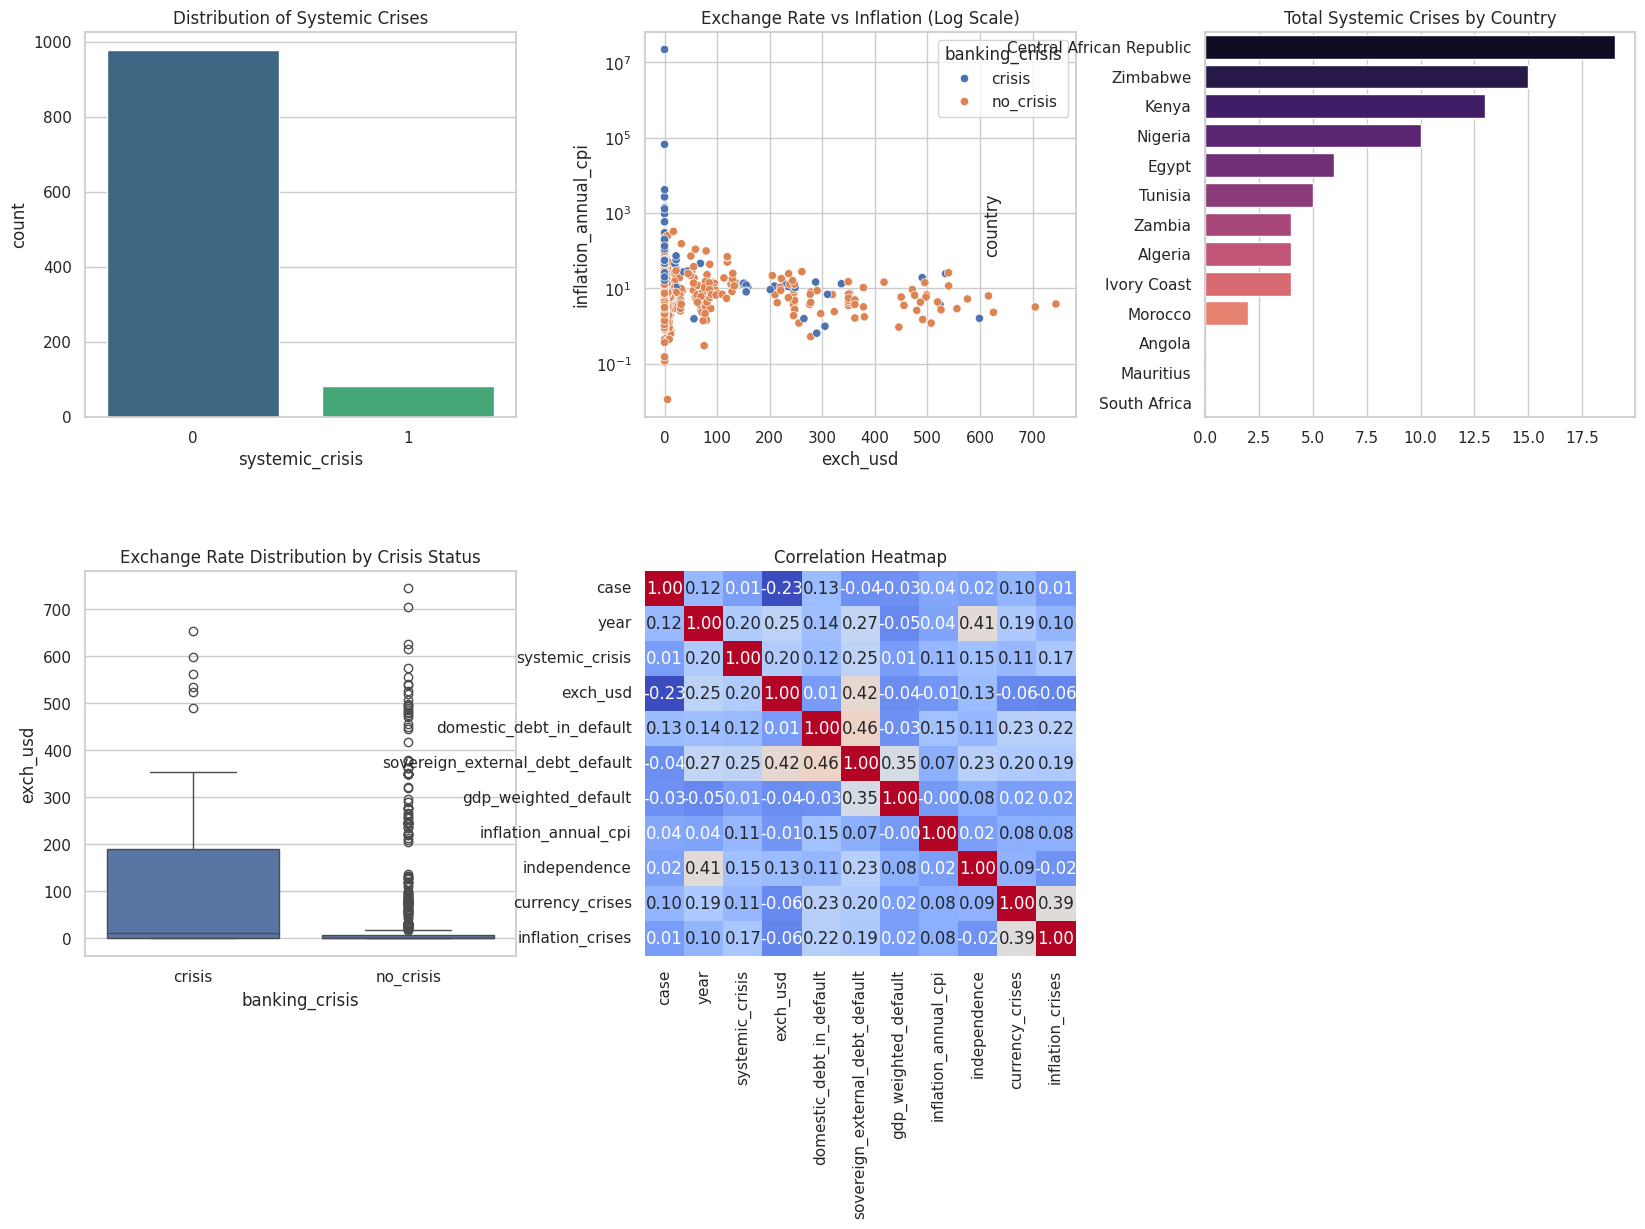

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Histogram: Systemic Crisis frequency
sns.countplot(data=df, x='systemic_crisis', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Distribution of Systemic Crises')

# 2. Scatter Plot: Exchange Rate vs Inflation (Log scale for high inflation)
sns.scatterplot(data=df, x='exch_usd', y='inflation_annual_cpi', hue='banking_crisis', ax=axes[0, 1])
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Exchange Rate vs Inflation (Log Scale)')

# 3. Bar Chart: Total Crises by Country
country_crises = df.groupby('country')['systemic_crisis'].sum().sort_values(ascending=False)
sns.barplot(x=country_crises.values, y=country_crises.index, ax=axes[0, 2], palette='magma')
axes[0, 2].set_title('Total Systemic Crises by Country')

# 4. Box Plot: Exchange Rate by Banking Crisis
sns.boxplot(data=df, x='banking_crisis', y='exch_usd', ax=axes[1, 0])
axes[1, 0].set_title('Exchange Rate Distribution by Crisis Status')

# 5. Correlation Heatmap
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1], cbar=False)
axes[1, 1].set_title('Correlation Heatmap')

# Remove the empty 6th subplot
fig.delaxes(axes[1, 2])

plt.show()